Installing Packages

In [1]:
!pip install lightgbm shap -q
print("✅ Packages installed")

✅ Packages installed


 Generating Synthetic User Event Data

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Define event types (Revolut-style funnel)
event_types = [
    'app_opened',
    'account_created',
    'kyc_started',
    'kyc_completed',
    'deposit_made',
    'transaction_made',
    'credit_product_viewed',
    'credit_application_started',
    'credit_application_completed',
    'credit_application_cancelled'
]

# Define conversion probabilities (realistic drop-off rates)
conversion_probs = {
    'account_created': 0.85,
    'kyc_started': 0.70,
    'kyc_completed': 0.60,
    'deposit_made': 0.50,
    'transaction_made': 0.80,
    'credit_application_started': 0.30,
    'credit_application_completed': 0.40
}

NUM_USERS = 5000

def generate_user_events(user_id):
    """Generate event sequence for a single user"""
    events = []
    signup_date = datetime.now() - timedelta(days=random.randint(45, 90))

    events.append({
        'user_id': user_id,
        'event_type': 'app_opened',
        'timestamp': signup_date + timedelta(hours=random.randint(1, 24))
    })

    current_date = signup_date

    if random.random() < conversion_probs['account_created']:
        current_date += timedelta(hours=random.randint(1, 48))
        events.append({'user_id': user_id, 'event_type': 'account_created', 'timestamp': current_date})

        if random.random() < conversion_probs['kyc_started']:
            current_date += timedelta(hours=random.randint(1, 72))
            events.append({'user_id': user_id, 'event_type': 'kyc_started', 'timestamp': current_date})

            if random.random() < conversion_probs['kyc_completed']:
                current_date += timedelta(hours=random.randint(24, 120))
                events.append({'user_id': user_id, 'event_type': 'kyc_completed', 'timestamp': current_date})

                if random.random() < conversion_probs['deposit_made']:
                    current_date += timedelta(hours=random.randint(1, 48))
                    events.append({'user_id': user_id, 'event_type': 'deposit_made', 'timestamp': current_date})

                    if random.random() < conversion_probs['transaction_made']:
                        current_date += timedelta(hours=random.randint(1, 24))
                        events.append({'user_id': user_id, 'event_type': 'transaction_made', 'timestamp': current_date})

                        if random.random() < conversion_probs['credit_application_started']:
                            current_date += timedelta(days=random.randint(1, 14))
                            events.append({'user_id': user_id, 'event_type': 'credit_product_viewed', 'timestamp': current_date})

                            current_date += timedelta(hours=random.randint(1, 48))
                            events.append({'user_id': user_id, 'event_type': 'credit_application_started', 'timestamp': current_date})

                            if random.random() < conversion_probs['credit_application_completed']:
                                current_date += timedelta(hours=random.randint(1, 24))
                                events.append({'user_id': user_id, 'event_type': 'credit_application_completed', 'timestamp': current_date})
                            else:
                                current_date += timedelta(hours=random.randint(1, 24))
                                events.append({'user_id': user_id, 'event_type': 'credit_application_cancelled', 'timestamp': current_date})
    return events

print("Generating events for 5,000 users...")
all_events = []
for user_id in range(1, NUM_USERS + 1):
    if user_id % 1000 == 0:
        print(f"Processed {user_id}/{NUM_USERS} users")
    all_events.extend(generate_user_events(user_id))

df_events = pd.DataFrame(all_events)
print(f"\n✅ Generated {len(df_events)} events for {NUM_USERS} users")

print("\n📊 Event type breakdown:")
print(df_events['event_type'].value_counts())

Generating events for 5,000 users...
Processed 1000/5000 users
Processed 2000/5000 users
Processed 3000/5000 users
Processed 4000/5000 users
Processed 5000/5000 users

✅ Generated 16149 events for 5000 users

📊 Event type breakdown:
event_type
app_opened                      5000
account_created                 4222
kyc_started                     2950
kyc_completed                   1758
deposit_made                     889
transaction_made                 715
credit_product_viewed            205
credit_application_started       205
credit_application_cancelled     133
credit_application_completed      72
Name: count, dtype: int64


 Funnel Analysis (SQL-style in Python)

In [3]:
# Calculate funnel using pandas (equivalent to SQL)
funnel_counts = {}
for event in event_types:
    count = df_events[df_events['event_type'] == event]['user_id'].nunique()
    funnel_counts[event] = count

print("📈 FUNNEL ANALYSIS")
print("="*50)
print(f"App Opened:              {funnel_counts['app_opened']} users")
print(f"Account Created:         {funnel_counts['account_created']} users ({funnel_counts['account_created']/funnel_counts['app_opened']*100:.1f}%)")
print(f"KYC Started:             {funnel_counts['kyc_started']} users ({funnel_counts['kyc_started']/funnel_counts['account_created']*100:.1f}%)")
print(f"KYC Completed:           {funnel_counts['kyc_completed']} users ({funnel_counts['kyc_completed']/funnel_counts['kyc_started']*100:.1f}%)")
print(f"First Deposit:           {funnel_counts['deposit_made']} users ({funnel_counts['deposit_made']/funnel_counts['kyc_completed']*100:.1f}%)")
print(f"First Transaction:       {funnel_counts['transaction_made']} users ({funnel_counts['transaction_made']/funnel_counts['deposit_made']*100:.1f}%)")
print(f"Credit Application:      {funnel_counts['credit_application_completed']} users ({funnel_counts['credit_application_completed']/funnel_counts['transaction_made']*100:.1f}%)")

📈 FUNNEL ANALYSIS
App Opened:              5000 users
Account Created:         4222 users (84.4%)
KYC Started:             2950 users (69.9%)
KYC Completed:           1758 users (59.6%)
First Deposit:           889 users (50.6%)
First Transaction:       715 users (80.4%)
Credit Application:      72 users (10.1%)


Feature Engineering

In [4]:
from datetime import datetime

df = df_events.sort_values(['user_id', 'timestamp'])
features = {}

for user_id in df['user_id'].unique():
    user_events = df[df['user_id'] == user_id].copy()
    user_features = {}

    # Session metrics
    if len(user_events) > 1:
        time_diffs = user_events['timestamp'].diff().dt.total_seconds().dropna()
        user_features['median_session_gap_hours'] = time_diffs.median() / 3600
        user_features['session_gap_std_hours'] = time_diffs.std() / 3600
    else:
        user_features['median_session_gap_hours'] = 0
        user_features['session_gap_std_hours'] = 0

    # Peak velocity
    user_events['hour_window'] = user_events['timestamp'].dt.floor('2H')
    velocity = user_events.groupby('hour_window').size()
    user_features['peak_velocity_events_per_2h'] = velocity.max() if len(velocity) > 0 else 0

    # Cancellation metrics
    cancellations = user_events[user_events['event_type'] == 'credit_application_cancelled'].shape[0]
    credit_starts = user_events[user_events['event_type'] == 'credit_application_started'].shape[0]
    user_features['cancellation_ratio'] = cancellations / max(1, credit_starts)

    # Funnel completion
    user_features['completed_kyc'] = 1 if 'kyc_completed' in user_events['event_type'].values else 0
    user_features['made_deposit'] = 1 if 'deposit_made' in user_events['event_type'].values else 0
    user_features['made_transaction'] = 1 if 'transaction_made' in user_events['event_type'].values else 0
    user_features['completed_credit'] = 1 if 'credit_application_completed' in user_events['event_type'].values else 0

    # Activity spike detection
    user_events['date'] = user_events['timestamp'].dt.date
    daily_counts = user_events.groupby('date').size()
    avg_daily = daily_counts.mean() if len(daily_counts) > 0 else 1
    spike_days = daily_counts[daily_counts > 3 * avg_daily].shape[0]
    user_features['has_activity_spike'] = 1 if spike_days > 0 else 0

    # Event diversity
    unique_events = user_events['event_type'].nunique()
    user_features['event_type_diversity'] = unique_events / len(df_events['event_type'].unique())

    features[user_id] = user_features

df_features = pd.DataFrame.from_dict(features, orient='index')
df_features.index.name = 'user_id'
df_features = df_features.reset_index()

print(f"✅ Engineered {df_features.shape[1]} features for {df_features.shape[0]} users")
print("\n📊 Feature summary:")
print(df_features.describe())

Streaming output truncated to the last 5000 lines.
/tmp/ipykernel_3024/931825956.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  user_events['hour_window'] = user_events['timestamp'].dt.floor('2H')
/tmp/ipykernel_3024/931825956.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  user_events['hour_window'] = user_events['timestamp'].dt.floor('2H')
/tmp/ipykernel_3024/931825956.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  user_events['hour_window'] = user_events['timestamp'].dt.floor('2H')
/tmp/ipykernel_3024/931825956.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  user_events['hour_window'] = user_events['timestamp'].dt.floor('2H')
/tmp/ipykernel_3024/931825956.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h'

✅ Engineered 11 features for 5000 users

📊 Feature summary:
           user_id  median_session_gap_hours  session_gap_std_hours  \
count  5000.000000               5000.000000            3728.000000   
mean   2500.500000                 20.743200              21.621159   
std    1443.520003                 15.607731              19.683523   
min       1.000000                  0.000000               0.000000   
25%    1250.750000                  7.000000               3.535534   
50%    2500.500000                 20.000000              19.924859   
75%    3750.250000                 31.500000              33.741652   
max    5000.000000                 72.000000             113.671755   

       peak_velocity_events_per_2h  cancellation_ratio  completed_kyc  \
count                  5000.000000         5000.000000    5000.000000   
mean                      1.049800            0.026600       0.351600   
std                       0.219385            0.160927       0.477518   
min     

Train Model with SHAP

Target distribution:
completed_credit
0    0.9856
1    0.0144
Name: proportion, dtype: float64
Train: 4000 users | Test: 1000 users

📊 AUC Score: 1.0000

📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       986
           1       1.00      1.00      1.00        14

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_3024/3366018908.py:48: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)


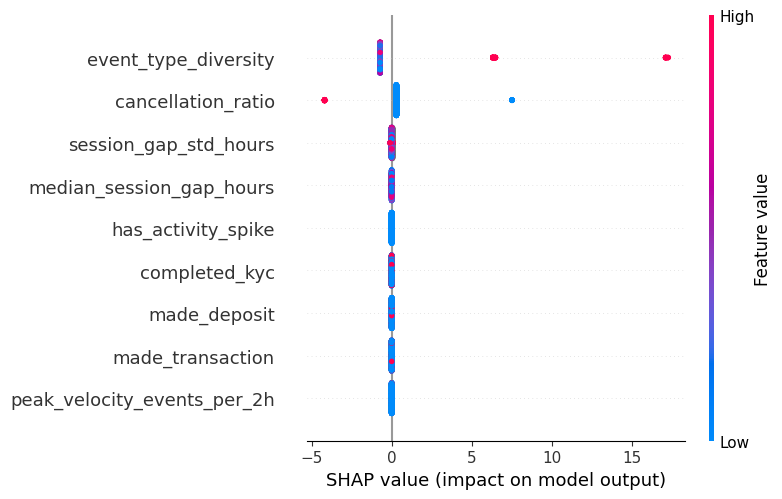


📊 TOP 10 FEATURES BY SHAP IMPORTANCE:
                       feature  importance
8         event_type_diversity    1.115474
3           cancellation_ratio    0.506253
1        session_gap_std_hours    0.006868
0     median_session_gap_hours    0.000361
2  peak_velocity_events_per_2h    0.000000
4                completed_kyc    0.000000
5                 made_deposit    0.000000
6             made_transaction    0.000000
7           has_activity_spike    0.000000


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

# Define target
target = 'completed_credit'

# Select features
feature_cols = [col for col in df_features.columns if col not in ['user_id', target]]
X = df_features[feature_cols]
y = df_features[target]

print(f"Target distribution:\n{y.value_counts(normalize=True)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape[0]} users | Test: {X_test.shape[0]} users")

# Train model
model = lgb.LGBMClassifier(
    objective='binary',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)

# Predictions
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Metrics
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n📊 AUC Score: {auc:.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

# SHAP Analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Top features
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 FEATURES BY SHAP IMPORTANCE:")
print(shap_importance.head(10))

Business Recoomendation


In [6]:
print("\n" + "="*60)
print("💡 BUSINESS RECOMMENDATIONS (Based on SHAP Analysis)")
print("="*60)

top_features = shap_importance.head(3)['feature'].tolist()
print(f"\nTop 3 predictive features: {top_features}")

recommendations = {
    'median_session_gap_hours': "Users with shorter time between sessions are more likely to complete credit applications. ACTION: Send re-engagement notifications to users inactive >48 hours.",
    'peak_velocity_events_per_2h': "Users who interact intensely in short bursts show higher credit completion. ACTION: Identify 'power users' early and fast-track credit offers.",
    'has_activity_spike': "Activity spikes predict completion. ACTION: Trigger credit product recommendations when users show unusual engagement increases.",
    'cancellation_ratio': "Users who cancel applications are higher risk. ACTION: Implement in-app support during credit application flow.",
    'event_type_diversity': "Users who explore more product features are more engaged. ACTION: Cross-sell credit to users already using 3+ features."
}

for feat in top_features:
    if feat in recommendations:
        print(f"\n🔹 {feat}:")
        print(f"   {recommendations[feat]}")


💡 BUSINESS RECOMMENDATIONS (Based on SHAP Analysis)

Top 3 predictive features: ['event_type_diversity', 'cancellation_ratio', 'session_gap_std_hours']

🔹 event_type_diversity:
   Users who explore more product features are more engaged. ACTION: Cross-sell credit to users already using 3+ features.

🔹 cancellation_ratio:
   Users who cancel applications are higher risk. ACTION: Implement in-app support during credit application flow.


Save

In [11]:
from google.colab import files

# Download the feature engineering results
df_features.to_csv('engineered_features.csv', index=False)
files.download('engineered_features.csv')

# Download the events data
df_events.to_csv('user_events.csv', index=False)
files.download('user_events.csv')

# Download the SHAP plot
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
files.download('shap_summary_plot.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [12]:
from google.colab import files
files.download('user_events.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

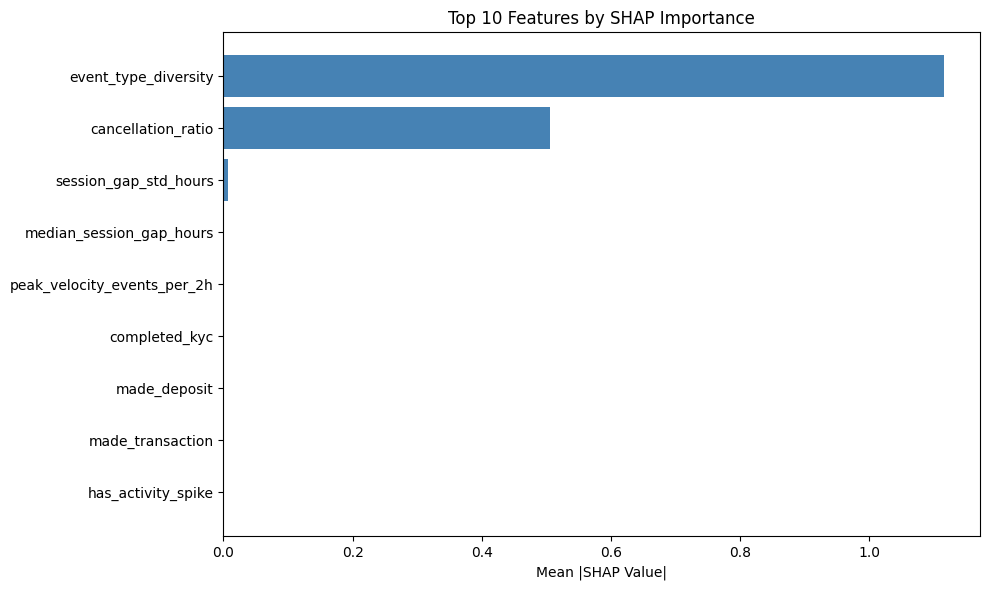

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started. Check your Downloads folder.


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from google.colab import files

# Calculate mean absolute SHAP values per feature
shap_mean_abs = np.abs(shap_values).mean(axis=0)

# Create dataframe of feature importance
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': shap_mean_abs
}).sort_values('importance', ascending=False).head(10)

# Create bar chart
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Mean |SHAP Value|')
plt.title('Top 10 Features by SHAP Importance')
plt.gca().invert_yaxis()
plt.tight_layout()

# Save
plt.savefig('shap_importance_bars.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Download
files.download('shap_importance_bars.png')

print("\n✅ Download started. Check your Downloads folder.")